# Customer Personality Analysis — Clustering & Response Modeling

**Pipeline:** PCA → KMeans clustering → feature engineering → ablation study →
hyperparameter tuning → model comparison (Random Forest / Logistic Regression / XGBoost)

**Core question:** does knowing a customer's *behavioural cluster* (built from CRM
spend + engagement data) improve campaign-response prediction beyond demographics
and digital-behaviour signals alone?

This notebook is organized into two halves:
1. **Unsupervised** — PCA on spend categories, then KMeans to segment customers.
2. **Supervised** — predict campaign response (`response`), using an ablation study
   to isolate the value of each data source (demographic / digital / CRM-hybrid / global),
   followed by tuning and a statistical model comparison.

## Setup

In [15]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score
from scipy.stats import ttest_ind
from xgboost import XGBClassifier
from MLstatkit.stats import Delong_test

from scipy.stats import chi2_contingency


# Brand palette, reused across every chart in this notebook
CARD   = "#2B2B2B"
BORDER = "#988E6E"
TEXT   = "#6D1F3A"
ACCENT = "#C4B89A"
DIM    = "dimgray"

In [16]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

data = pd.read_csv(config["data"]["clean"]["file3"], quotechar='"', sep=";")
data.shape

(2212, 24)

## Part 1 — PCA on spending behaviour

Six spend columns (`wines`, `fruits`, `meat`, `fish`, `sweets`, `gold`) are highly
correlated with each other and with overall spend level. Feeding all six raw into
KMeans would let total spend dominate the distance metric. PCA compresses them into
a small number of orthogonal "spend axes" (e.g. *overall spend* vs *luxury mix*)
that carry the same signal with less redundancy, before clustering.

In [17]:
pca_cols = ['wines', 'fruits', 'meat', 'fish', 'sweets', 'gold']
pca_data = data[pca_cols]

scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

**How many components?** Fit PCA with no component limit, then look at cumulative
explained variance. We use a 75% threshold as a (fairly conservative) cutoff.

In [18]:
pca = PCA()
pca.fit(pca_data_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.75) + 1
print(f"Components needed for 75% variance: {d}")
cumsum

Components needed for 75% variance: 3


array([0.56308306, 0.68755201, 0.80136403, 0.87322664, 0.94148251,
       1.        ])

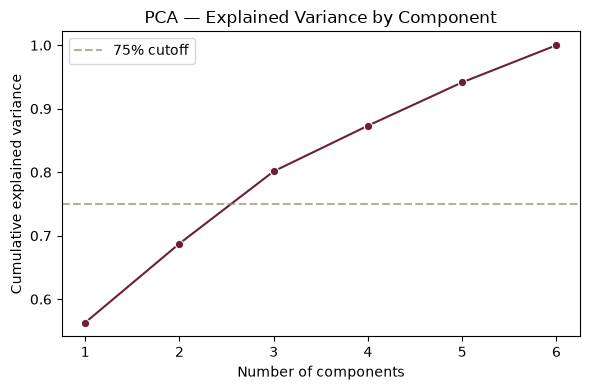

In [19]:
plt.figure(figsize=(6, 4))
sns.lineplot(x=range(1, len(cumsum) + 1), y=cumsum, marker="o", color=TEXT)
plt.axhline(0.75, color=BORDER, linestyle="--", alpha=0.7, label="75% cutoff")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Explained Variance by Component")
plt.legend()
plt.tight_layout()
plt.show()

There's a visible elbow at 2 components, but 2 components alone only explain
just under 70% of variance — below our 75% cutoff. We take **3 components** as
the practical compromise: past the elbow, but clears the variance bar.

In [20]:
pca_3 = PCA(n_components=3)
X_pca = pca_3.fit_transform(pca_data_scaled)

df_pca_scores = pd.DataFrame(X_pca, columns=["Spend_PC1", "Spend_PC2", "Spend_PC3"])

# Clustering feature set: PCA-compressed spend axes + raw demographic/channel signals.
# Income, has_child, and channel usage are kept un-transformed (not part of the PCA)
# because they're already low-dimensional and interpretable on their own — no need
# to compress what isn't redundant.
X_cluster = pd.concat([
    df_pca_scores,
    data[['income', 'has_child', 'web', 'catalogue', 'store']].reset_index(drop=True)
], axis=1)

X_cluster.head()

,Spend_PC1,Spend_PC2,Spend_PC3,income,has_child,web,catalogue,store
0,3.761585,-0.648391,0.000278,58138.0,False,8,10,4
1,-1.715110,-0.315942,0.024706,46344.0,True,1,1,2
2,0.812383,-0.313398,0.127833,71613.0,False,8,2,10
3,-1.577348,-0.408569,0.016537,26646.0,True,2,0,4
4,-0.186176,-0.734053,-0.041563,58293.0,True,5,3,6


**What does each component represent?** Plot the loadings (weights) of each spend
category on PC1, then all three components as a heatmap, to interpret what each
axis captures.

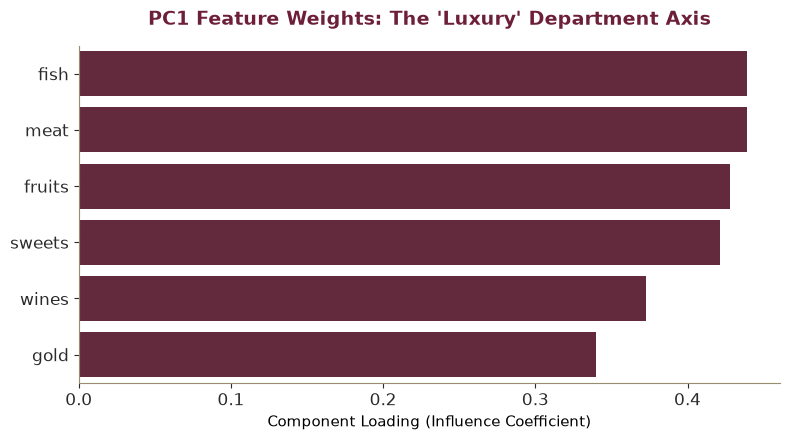

In [21]:
pc1_loadings = pca_3.components_[0]
df_pc1 = pd.DataFrame({'Department': pca_cols, 'Weight': pc1_loadings})
df_pc1 = df_pc1.sort_values(by='Weight', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')

colors = [TEXT if x > 0 else '#C4A4A4' for x in df_pc1['Weight']]

sns.barplot(x='Weight', y='Department', data=df_pc1, hue='Department',
            palette=colors, legend=False, ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.tick_params(colors=CARD, labelsize=12)
ax.axvline(x=0, color=BORDER, linestyle='--', alpha=0.7)

plt.title("PC1 Feature Weights: The 'Luxury' Department Axis", color=TEXT, fontsize=14, pad=15, weight='bold')
plt.xlabel("Component Loading (Influence Coefficient)", fontsize=11)
plt.ylabel("")
plt.tight_layout()
plt.savefig('../figures/pca_loadings.png', transparent=True, dpi=300)
plt.show()

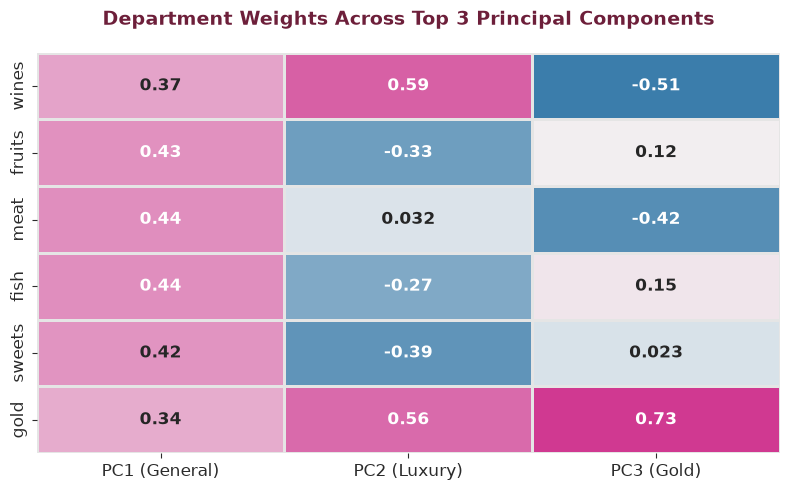

In [22]:
pca_loadings_df = pd.DataFrame(
    {
        'PC1 (General)': pca_3.components_[0],
        'PC2 (Luxury)':  pca_3.components_[1],
        'PC3 (Gold)':    pca_3.components_[2],
    },
    index=pca_cols,
)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')

cmap = sns.diverging_palette(240, 340, s=80, l=50, as_cmap=True)

sns.heatmap(pca_loadings_df, annot=True, cmap=cmap, cbar=False, linewidths=1,
            linecolor='#E5E5E5', ax=ax, annot_kws={"size": 12, "weight": "bold"})

ax.tick_params(colors=CARD, labelsize=12)
plt.title("Department Weights Across Top 3 Principal Components", color=TEXT, fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.savefig('../figures/pca_heatmap.png', transparent=True, dpi=300)
plt.show()

## Part 2 — KMeans clustering

With the reduced feature set (`X_cluster`) in hand, find the number of segments
that gives the most coherent groupings. We scan k = 2 through 10 and track both
**silhouette score** (cluster separation/cohesion, higher is better) and inertia
(within-cluster variance, lower is better, always decreases with more k).

In [23]:
X_cluster_scaled = scaler.fit_transform(X_cluster)

k=2: silhouette=0.3845 inertia=11231.2000
k=3: silhouette=0.3635 inertia=9197.5660
k=4: silhouette=0.3575 inertia=8219.8209
k=5: silhouette=0.3488 inertia=7484.0170
k=6: silhouette=0.3387 inertia=6906.1590
k=7: silhouette=0.3052 inertia=6446.8935
k=8: silhouette=0.3025 inertia=6053.2225
k=9: silhouette=0.3077 inertia=5696.3444
k=10: silhouette=0.3024 inertia=5508.4359


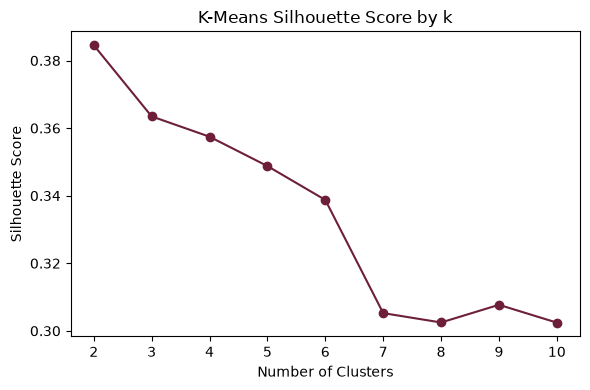

In [24]:
silhouette_scores = []
inertias = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)
    inertias.append(km.inertia_)
    print(f"k={k}: silhouette={score:.4f} inertia={km.inertia_:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(range(2, 11), silhouette_scores, marker="o", color=TEXT)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score by k")
plt.tight_layout()
plt.show()

**Choosing k=3.** Silhouette peaks at k=2–3 (they're close), and inertia drops
sharply moving from 2 to 3 clusters. We go with **3 clusters**: the fit is nearly
as tight as k=2, but 3 segments gives marketing more actionable granularity than
a simple high/low split.

In [25]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['Cluster'] = final_kmeans.fit_predict(X_cluster_scaled)

print(data['Cluster'].value_counts())

profile_cols = ['income', 'age', 'has_child', 'wines', 'meat', 'webvisits', 'total_spend', 'num_children']
data.groupby('Cluster')[profile_cols].mean()

Cluster
1    1059
2     643
0     510
Name: count, dtype: int64


,income,age,has_child,wines,meat,webvisits,total_spend,num_children
Cluster,,,,,,,,
0,76437.270588,45.764706,0.066667,604.380392,473.827451,2.670588,1382.535294,0.072549
1,34698.657224,42.973560,0.878187,45.217186,24.326723,6.459868,103.649669,1.241737
2,60970.455677,48.027994,0.958009,496.387247,158.718507,5.548989,821.802488,1.157076


In [26]:
data.to_csv("../data/clean/data_w_cluster.csv", index=False, encoding="utf-8", sep=";")
#data.to_csv("../data/clean/data_w_cluster.csv", index=False, encoding="utf-8", sep=",")

Project the clusters back onto 2D (via PCA on the clustering feature set) purely for visualization.

In [27]:
pca = PCA()
pca.fit(X_cluster_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.75) + 1
print(f"Components needed for 75% variance: {d}")
cumsum

Components needed for 75% variance: 4


array([0.45944757, 0.61669607, 0.74335343, 0.83475515, 0.89345445,
       0.94753473, 0.98159434, 1.        ])

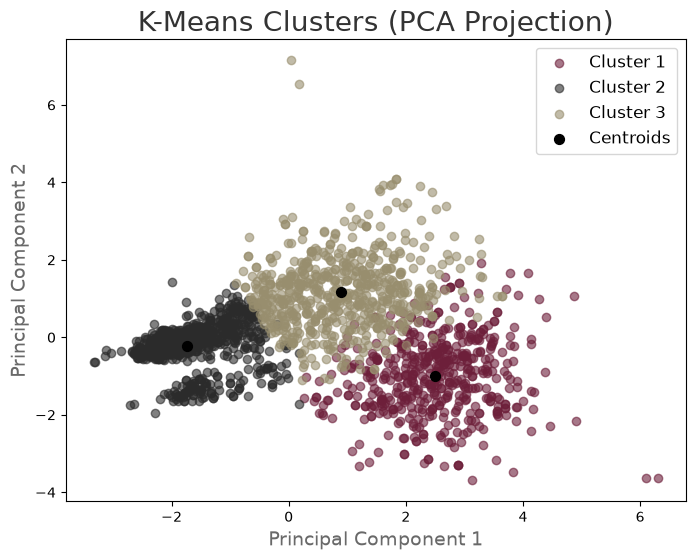

In [14]:
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_cluster_scaled)
centroids_pca = pca_viz.transform(final_kmeans.cluster_centers_)

colours_dict = {0: "#6D1F3A", 1: "#2B2B2B", 2: "#988E6E"}

plt.figure(figsize=(8, 6))
for i in range(3):
    mask = data['Cluster'] == i
    plt.scatter(X_pca_viz[mask, 0], X_pca_viz[mask, 1],
                label=f'Cluster {i + 1}', c=colours_dict[i], alpha=0.6)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', s=50, label='Centroids')

plt.xlabel("Principal Component 1", fontsize=14, color="dimgray")
plt.ylabel("Principal Component 2", fontsize=14, color="dimgray")
plt.title("K-Means Clusters (PCA Projection)", fontsize=20, color="0.2")
plt.legend(fontsize=12)
plt.savefig('../figures/pca_clusters.png', transparent=True, dpi=300)
plt.show()

## Part 3 — Feature engineering for the supervised model

Switching tracks: the target is now `response` (did the customer convert on the
latest campaign?). We assemble a feature table that mixes demographics, digital
behaviour, and CRM signals — including the `Cluster` label just derived — so we
can later test which of these groups actually drives predictive power.

Encoders and scalers are **fit on the training split only** and applied to test.

In [14]:
feature_cols = ['recency', 'num_camp_success', 'deals', 'webvisits', 'total_spend',
                'income', 'customer_tenure_in_days', 'age', 'education',
                'num_children', 'marital_status', 'Cluster']
features = data[feature_cols].copy()
target = data['response']

# Ordinal encoding — education has a natural order, so integer mapping preserves that
# information (a one-hot encoding would throw it away).
education_mapping = {'Undergraduate': 0, 'Postgraduate': 1, 'PhD': 2}
features['education'] = features['education'].map(education_mapping)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.20, random_state=0
)
X_train.shape, X_test.shape

((1769, 12), (443, 12))

In [16]:
# One-hot encode marital_status. drop='first' avoids the dummy-variable trap
# (one category becomes the implicit baseline).
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.fit(X_train[['marital_status']])

X_train_trans_df = pd.DataFrame(
    ohe.transform(X_train[['marital_status']]),
    columns=ohe.get_feature_names_out(), index=X_train.index
)
X_test_trans_df = pd.DataFrame(
    ohe.transform(X_test[['marital_status']]),
    columns=ohe.get_feature_names_out(), index=X_test.index
)

X_train_full = pd.concat([X_train_trans_df, X_train.drop(columns=['marital_status'])], axis=1)
X_test_full = pd.concat([X_test_trans_df, X_test.drop(columns=['marital_status'])], axis=1)

std_scaler = StandardScaler()
std_scaler.fit(X_train_full)

X_train_full_np_df = pd.DataFrame(
    std_scaler.transform(X_train_full), columns=X_train_full.columns, index=X_train_full.index
)
X_test_full_np_df = pd.DataFrame(
    std_scaler.transform(X_test_full), columns=X_test_full.columns, index=X_test_full.index
)

X_train_full_np_df.head()

,marital_status_Separated,marital_status_Single,recency,num_camp_success,deals,webvisits,total_spend,income,customer_tenure_in_days,age,education,num_children,Cluster
286,2.470712,-0.513392,-0.526307,1.031205,1.351093,-0.120957,0.499564,0.271996,-1.224443,0.32340,1.575161,0.078267,1.313702
933,2.470712,-0.513392,-0.629951,-0.445881,-0.170284,1.123072,0.629260,0.731565,1.414685,-0.53290,-1.943097,0.078267,1.313702
813,-0.404742,-0.513392,-0.906336,-0.445881,-0.677410,0.293719,-0.968140,-1.633462,-1.145071,-1.30357,-0.183968,0.078267,-0.075383
575,-0.404742,-0.513392,-0.837240,2.508292,-1.184536,-1.364986,2.420384,1.849064,1.057510,-0.53290,-0.183968,-1.265957,-1.464468
117,-0.404742,1.947829,-0.422663,-0.445881,-0.677410,-1.779662,2.152783,1.270930,0.412610,-1.30357,-0.183968,-1.265957,-1.464468


## Part 4 — Baseline Random Forest (all features)

A first pass using every available feature, to establish a baseline and sanity-check
feature importances before doing the ablation study properly.

In [17]:
forest = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight="balanced", random_state=42)
forest.fit(X_train_full_np_df, y_train)

y_pred_baseline = forest.predict(X_test_full_np_df)
print(f"Accuracy: {forest.score(X_test_full_np_df, y_test):.2f}")
print(classification_report(y_test, y_pred_baseline))

Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       378
           1       0.57      0.51      0.54        65

    accuracy                           0.87       443
   macro avg       0.74      0.72      0.73       443
weighted avg       0.87      0.87      0.87       443



In [18]:
pd.Series(forest.feature_importances_, index=X_train_full_np_df.columns).sort_values(ascending=False)

recency                     0.161213
total_spend                 0.143897
customer_tenure_in_days     0.141769
num_camp_success            0.140599
income                      0.103698
age                         0.080049
webvisits                   0.064790
deals                       0.043793
Cluster                     0.028958
num_children                0.027775
education                   0.025906
marital_status_Single       0.021461
marital_status_Separated    0.016093
dtype: float64

## Part 5 — Ablation study: which data source actually matters?

This is the core comparison for the capstone argument. Four feature sets, same
model type, same train/test split:

- **Demographics** — age, income, education, family status
- **Digital** — web visits, deals used, recency (behavioural/cookie-style signals)
- **Hybrid / CRM** — tenure, past campaign success, cluster segment, total spend
  (first-party relationship data)
- **Global** — everything combined

If the CRM-hybrid set performs close to the Global model while beating pure
digital-behaviour signals, that supports the thesis that first-party CRM data is
doing more work than cookie-style behavioural data for targeting.

In [19]:
demo_cols = ['age', 'income', 'education', 'num_children',
             'marital_status_Single', 'marital_status_Separated']
digital_cols = ['webvisits', 'deals', 'recency']
hybrid_cols = ['customer_tenure_in_days', 'num_camp_success', 'Cluster', 'total_spend']
global_cols = list(X_train_full_np_df.columns)

feature_sets = {
    "Model A (Demographics)": demo_cols,
    "Model B (Digital)": digital_cols,
    "Model C (Relationship/Hybrid)": hybrid_cols,
    "Global Model (All Data)": global_cols,
}

for model_name, cols in feature_sets.items():
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_full_np_df[cols], y_train)

    probs = rf.predict_proba(X_test_full_np_df[cols])[:, 1]
    preds = rf.predict(X_test_full_np_df[cols])

    print(f"=== {model_name} ===")
    print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
    print(classification_report(y_test, preds))
    print("-" * 40)

=== Model A (Demographics) ===
ROC-AUC: 0.7018
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       378
           1       0.51      0.28      0.36        65

    accuracy                           0.86       443
   macro avg       0.70      0.62      0.64       443
weighted avg       0.83      0.86      0.84       443

----------------------------------------
=== Model B (Digital) ===
ROC-AUC: 0.6773
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       378
           1       0.32      0.23      0.27        65

    accuracy                           0.81       443
   macro avg       0.60      0.57      0.58       443
weighted avg       0.79      0.81      0.80       443

----------------------------------------
=== Model C (Relationship/Hybrid) ===
ROC-AUC: 0.7573
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       378
           1

## Part 6 — Hyperparameter tuning

Tune a Random Forest on the Hybrid/CRM feature set first (our model of interest),
constraining tree complexity and handling class imbalance, using 5-fold CV
optimizing for ROC-AUC.

In [20]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [2, 4, 6],
    'class_weight': ['balanced', 'balanced_subsample'],
}

grid_search_hybrid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_hybrid.fit(X_train_full_np_df[hybrid_cols], y_train)

print(f"Optimized Model C (Hybrid) Best CV ROC-AUC: {grid_search_hybrid.best_score_:.4f}")
print(f"Best Parameters: {grid_search_hybrid.best_params_}")

Optimized Model C (Hybrid) Best CV ROC-AUC: 0.8119
Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 5, 'min_samples_leaf': 6, 'n_estimators': 100}


In [21]:
best_model_c = grid_search_hybrid.best_estimator_
probs_tuned = best_model_c.predict_proba(X_test_full_np_df[hybrid_cols])[:, 1]
preds_tuned = best_model_c.predict(X_test_full_np_df[hybrid_cols])

print(f"Tuned Model C Test ROC-AUC: {roc_auc_score(y_test, probs_tuned):.4f}")
print(classification_report(y_test, preds_tuned))

Tuned Model C Test ROC-AUC: 0.8086
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       378
           1       0.34      0.57      0.43        65

    accuracy                           0.77       443
   macro avg       0.63      0.69      0.64       443
weighted avg       0.83      0.77      0.80       443



In [22]:
model_names, auc_scores = [], []

for model_name, cols in feature_sets.items():
    rf = RandomForestClassifier(**grid_search_hybrid.best_params_, random_state=42)
    rf.fit(X_train_full_np_df[cols], y_train)
    probs = rf.predict_proba(X_test_full_np_df[cols])[:, 1]
    auc = roc_auc_score(y_test, probs)
    model_names.append(model_name)
    auc_scores.append(auc)
    print(f"{model_name}: {auc:.4f}")

Model A (Demographics): 0.7120
Model B (Digital): 0.7054
Model C (Relationship/Hybrid): 0.8086
Global Model (All Data): 0.8729


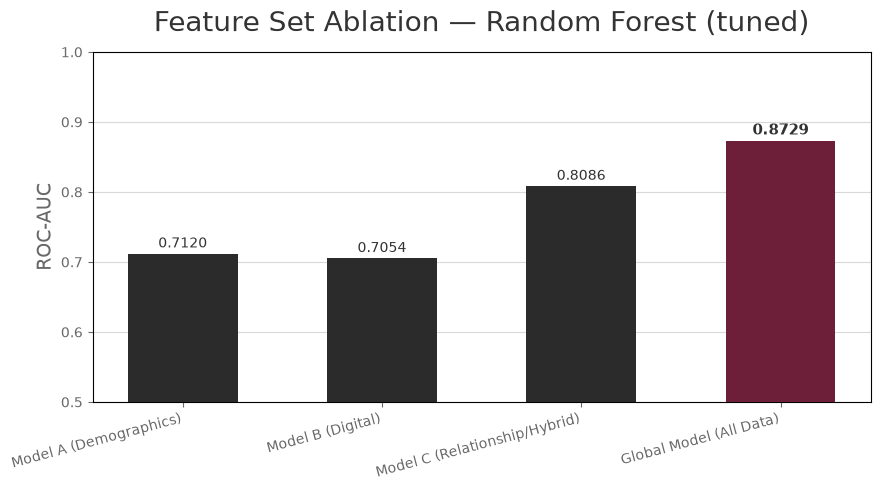

In [23]:
best_idx = auc_scores.index(max(auc_scores))
colors = [CARD] * len(auc_scores)
colors[best_idx] = TEXT

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bars = ax.bar(model_names, auc_scores, color=colors, width=0.55, zorder=3)

for i, (bar, score) in enumerate(zip(bars, auc_scores)):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.004, f"{score:.4f}",
            ha="center", va="bottom", fontsize=11 if i == best_idx else 10,
            color="0.2", fontweight="bold" if i == best_idx else "normal")

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=14, color=DIM)
ax.set_title("Feature Set Ablation — Random Forest (tuned)", fontsize=20, color="0.2", pad=15)
ax.tick_params(colors=DIM)
ax.yaxis.grid(True, alpha=0.25, color=DIM)
ax.set_axisbelow(True)
plt.xticks(rotation=15, ha="right", color=DIM)
plt.tight_layout()
plt.savefig('../figures/rf-ablation.png', transparent=True, dpi=300)
plt.show()

## Part 7 — Final tuned Random Forest (Global feature set)

Now tune specifically for the Global feature set, to get the strongest possible
RF as our headline "best of breed" model for the cross-algorithm comparison later.

In [24]:
grid_search_global = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_global.fit(X_train_full_np_df[global_cols], y_train)

print(f"Optimized Global Model ROC-AUC: {grid_search_global.best_score_:.4f}")
print(f"Best Parameters: {grid_search_global.best_params_}")

Optimized Global Model ROC-AUC: 0.8851
Best Parameters: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 200}


In [25]:
final_rf = RandomForestClassifier(**grid_search_global.best_params_, random_state=42)
final_rf.fit(X_train_full_np_df[global_cols], y_train)

probs_rf = final_rf.predict_proba(X_test_full_np_df[global_cols])[:, 1]
y_pred_rf = final_rf.predict(X_test_full_np_df[global_cols])

print("=== Final Optimized Global Random Forest ===")
print(f"ROC-AUC: {roc_auc_score(y_test, probs_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Final Optimized Global Random Forest ===
ROC-AUC: 0.8850
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       378
           1       0.45      0.69      0.54        65

    accuracy                           0.83       443
   macro avg       0.69      0.77      0.72       443
weighted avg       0.87      0.83      0.84       443



## Part 8 — Does the cluster label actually help?

The tree-based model above doesn't necessarily lean on `Cluster` even if it's
informative — decision trees can reconstruct similar splits directly from the raw
features that built the cluster in the first place. Check whether `Cluster`
correlates with response on its own, independent of what the RF chose to use.

In [26]:
data.groupby('Cluster')['response'].mean()

Cluster
0    0.301961
1    0.094429
2    0.122862
Name: response, dtype: float64

In [27]:
table = pd.crosstab(data['Cluster'], data['response'])
chi2, p, dof, expected = chi2_contingency(table)

print(f"Correct Chi-Square P-Value: {p}")

Correct Chi-Square P-Value: 4.422422497408337e-27


Cluster membership differs significantly between responders and non-responders.
That means it's a real signal — even if a tree-based model doesn't need it
explicitly (because it can split on the underlying spend/income features directly),
a model that can't reconstruct nonlinear cluster boundaries on its own, like
**logistic regression**, should benefit more from `Cluster` being handed to it
as a ready-made feature. Test that next.

## Part 9 — Logistic Regression

A linear baseline, then tuned via grid search, then a direct ablation of the
`Cluster` feature to see if it earns its place in a linear model the way the
hypothesis in Part 8 predicts.

In [28]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_full_np_df, y_train)

y_pred = log_reg.predict(X_test_full_np_df)
probs = log_reg.predict_proba(X_test_full_np_df)[:, 1]

print(f"Accuracy: {log_reg.score(X_test_full_np_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.90
ROC-AUC: 0.8616
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       378
           1       0.76      0.45      0.56        65

    accuracy                           0.90       443
   macro avg       0.84      0.71      0.75       443
weighted avg       0.89      0.90      0.89       443



In [29]:
param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': np.logspace(-3, 3, 10),
    'solver': ['saga'],
    'l1_ratio': [0, 0.5, 1],  # only used for elasticnet
    'max_iter': [1000],
}

grid_search_lr = GridSearchCV(LogisticRegression(max_iter=10000), param_grid_lr, cv=5)
grid_search_lr.fit(X_train_full_np_df, y_train)

print("Best parameters:", grid_search_lr.best_params_)

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, 

Best parameters: {'C': np.float64(0.1), 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}


C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Grid search's suggested combination doesn't always converge as cleanly as a
simpler, nearby setting. Here we use a stable, regularized L2/lbfgs configuration
close to the grid search optimum rather than the exact winning combination —
prioritizing a solver that reliably converges over squeezing out the last bit of
CV score.

In [30]:
log_reg = LogisticRegression(random_state=42, C=0.1, max_iter=1000, penalty='l2', solver='lbfgs')
log_reg.fit(X_train_full_np_df, y_train)

y_pred = log_reg.predict(X_test_full_np_df)
probs_lr = log_reg.predict_proba(X_test_full_np_df)[:, 1]

print(f"Accuracy: {log_reg.score(X_test_full_np_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs_lr):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.89
ROC-AUC: 0.8630
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       378
           1       0.75      0.42      0.53        65

    accuracy                           0.89       443
   macro avg       0.83      0.70      0.74       443
weighted avg       0.88      0.89      0.88       443



C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [31]:
# Ablation: same model, Cluster feature removed
log_reg_no_cluster = LogisticRegression(random_state=42, C=0.1, max_iter=1000, penalty='l2', solver='lbfgs')
log_reg_no_cluster.fit(X_train_full_np_df.drop(columns=['Cluster']), y_train)

y_pred_nc = log_reg_no_cluster.predict(X_test_full_np_df.drop(columns=['Cluster']))
probs_nc = log_reg_no_cluster.predict_proba(X_test_full_np_df.drop(columns=['Cluster']))[:, 1]

print(f"Accuracy (no Cluster): {log_reg_no_cluster.score(X_test_full_np_df.drop(columns=['Cluster']), y_test):.2f}")
print(f"ROC-AUC (no Cluster): {roc_auc_score(y_test, probs_nc):.4f}")
print(classification_report(y_test, y_pred_nc))

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy (no Cluster): 0.90
ROC-AUC (no Cluster): 0.8562
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       378
           1       0.77      0.42      0.54        65

    accuracy                           0.90       443
   macro avg       0.84      0.70      0.74       443
weighted avg       0.89      0.90      0.88       443



## Part 10 — XGBoost

Gradient-boosted trees as a third algorithm family. We go straight to
`XGBClassifier` (tuned via grid search) rather than starting from a regressor —
a classifier gives calibrated class probabilities natively via `predict_proba`,
which is what the ROC-AUC comparison and DeLong tests below both need.

In [32]:
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.3],
}

xgb_base = XGBClassifier(n_estimators=100, objective='binary:logistic', random_state=42)
grid_search_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb, cv=3, n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train_full_np_df, y_train)

print("Best parameters:", grid_search_xgb.best_params_)
print(f"Best CV score: {grid_search_xgb.best_score_:.4f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8}
Best CV score: 0.8886


In [33]:
xgb_clf = XGBClassifier(**grid_search_xgb.best_params_, n_estimators=100, random_state=42)
xgb_clf.fit(X_train_full_np_df, y_train)

y_pred_xgb = xgb_clf.predict(X_test_full_np_df)
probs_xgb = xgb_clf.predict_proba(X_test_full_np_df)[:, 1]

print(f"Accuracy: {xgb_clf.score(X_test_full_np_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.90
ROC-AUC: 0.9015
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       378
           1       0.74      0.45      0.56        65

    accuracy                           0.90       443
   macro avg       0.83      0.71      0.75       443
weighted avg       0.89      0.90      0.88       443



In [34]:
pd.Series(xgb_clf.feature_importances_, index=X_train_full_np_df.columns).sort_values(ascending=False)

num_camp_success            0.214292
recency                     0.102865
marital_status_Single       0.090950
Cluster                     0.076642
total_spend                 0.075456
customer_tenure_in_days     0.075374
marital_status_Separated    0.073372
webvisits                   0.061249
income                      0.056697
education                   0.050698
num_children                0.047033
deals                       0.041535
age                         0.033836
dtype: float32

## Part 11 — Model comparison with statistical significance

Comparing ROC-AUC scores directly is easy to over-interpret — a 0.01 AUC gap
could easily be noise on one held-out test set. The **DeLong test** compares two
ROC curves computed on the *same* test set (accounting for their correlation)
and returns a p-value for whether the AUC difference is statistically meaningful.

In [35]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_rf, probs_lr, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Random Forest AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"Logistic Regression AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")

=== DeLong Test ===
Samples: total=443, pos=65, neg=378
Tie rate: A=0.036, B=0.036
Step 1) Attempt standard DeLong.
[delong] z = -1.337495, p = 1.811e-01
Random Forest AUC: 0.8850, CI = (0.8454433412206533, 0.9246014288241166)
Logistic Regression AUC: 0.8630, CI = (0.8135914428494079, 0.912334483076518)
z = -1.3375, p = 1.811e-01


In [36]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_rf, probs_xgb, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Random Forest AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"XGBoost AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")

=== DeLong Test ===
Samples: total=443, pos=65, neg=378
Tie rate: A=0.036, B=0.036
Step 1) Attempt standard DeLong.
[delong] z = 2.158334, p = 3.090e-02
Random Forest AUC: 0.8850, CI = (0.8454433412206533, 0.9246014288241166)
XGBoost AUC: 0.9015, CI = (0.8636963921709835, 0.9393968109222195)
z = 2.1583, p = 3.090e-02


In [37]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_lr, probs_xgb, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Logistic Regression AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"XGBoost AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")

=== DeLong Test ===
Samples: total=443, pos=65, neg=378
Tie rate: A=0.036, B=0.036
Step 1) Attempt standard DeLong.
[delong] z = 2.977276, p = 2.908e-03
Logistic Regression AUC: 0.8630, CI = (0.8135914428494079, 0.912334483076518)
XGBoost AUC: 0.9015, CI = (0.8636963921709835, 0.9393968109222195)
z = 2.9773, p = 2.908e-03


## Final visual: head-to-head AUC comparison across all three algorithms.

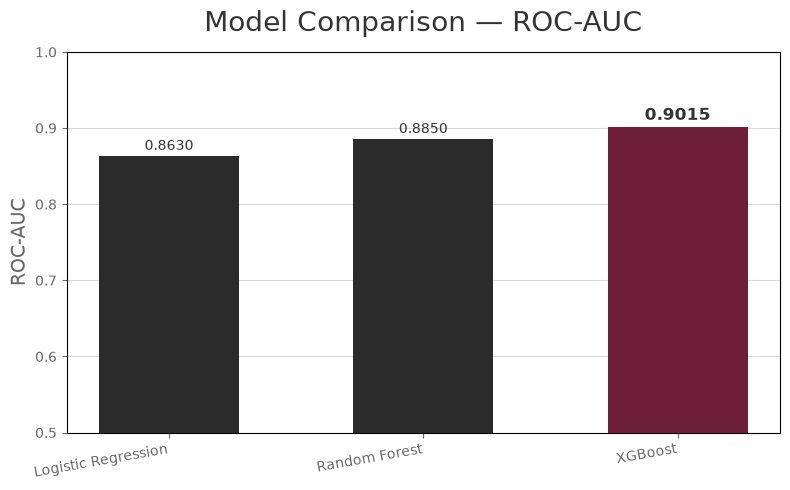

In [38]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]
probs_list = [probs_lr, probs_rf, probs_xgb]
auc_scores_final = [roc_auc_score(y_test, p) for p in probs_list]

best_idx = auc_scores_final.index(max(auc_scores_final))
colors = [CARD] * len(models)
colors[best_idx] = TEXT

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bars = ax.bar(models, auc_scores_final, color=colors, width=0.55, zorder=3)

for i, (bar, score) in enumerate(zip(bars, auc_scores_final)):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.004, f"{score:.4f}",
            ha="center", va="bottom", fontsize=12 if i == best_idx else 10,
            color="0.2", fontweight="bold" if i == best_idx else "normal")

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=14, color=DIM)
ax.set_title("Model Comparison — ROC-AUC", fontsize=20, color="0.2", pad=15)
ax.tick_params(colors=DIM)
ax.yaxis.grid(True, alpha=0.25, color=DIM)
ax.set_axisbelow(True)
plt.xticks(rotation=10, ha="right", color=DIM)
plt.tight_layout()
plt.savefig('../figures/model-comparison.png', transparent=True, dpi=300)
plt.show()

### Booststrap confirms that higher reported precision for logistic regression was noise.
This disproves the hypothesis that logistic regression could be a better model for marketing campaigns with higher spends.

In [40]:
n_boot = 1000
diffs = []
n = len(y_test)
y_test_arr = y_test.values
rng = np.random.default_rng(42)

for _ in range(n_boot):
    idx = rng.choice(n, size=n, replace=True)
    y_boot = y_test_arr[idx]
    pred_lr_boot = (probs_lr[idx] >= 0.5).astype(int)
    pred_xgb_boot = (probs_xgb[idx] >= 0.5).astype(int)
    
    prec_lr = precision_score(y_boot, pred_lr_boot, zero_division=0)
    prec_xgb = precision_score(y_boot, pred_xgb_boot, zero_division=0)
    diffs.append(prec_lr - prec_xgb)

diffs = np.array(diffs)
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
print(f"Mean diff: {diffs.mean():.4f}, 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

Mean diff: 0.0075, 95% CI: [-0.0905, 0.1116]
